# Aerial GCP Pose Estimation - Error Analysis

This notebook performs a detailed audit and error analysis of our baseline multitask ResNet18 model on the validation dataset.

## Objectives:
1. Load validation samples and perform model inference.
2. Calculate Euclidean pixel error in the original image resolution space.
3. Identify the best 3 and worst 3 predictions.
4. Visualize the offsets using zoomed-in crops around the ground-truth keypoints.
5. Inspect classification failures.
6. Summarize failure modes.


In [1]:
import json
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

from dataset import get_train_val_split, GCPDataset, CLASS_MAPPING, REV_CLASS_MAPPING
from transforms import get_val_transforms
from model import GCPMultitaskModel

# Configuration
JSON_PATH = os.path.join("train_dataset", "train_dataset", "gcp_marks.json")
BASE_DIR = os.path.join("train_dataset", "train_dataset")
WEIGHTS_PATH = "best_model.pth"
IMG_SIZE = 224


In [2]:
# Load data split
_, val_keys, json_data = get_train_val_split(JSON_PATH, BASE_DIR, val_split=0.2)
val_tf = get_val_transforms(img_size=IMG_SIZE)
dataset = GCPDataset(BASE_DIR, val_keys, json_data, transform=val_tf)

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCPMultitaskModel(num_classes=3, pretrained=False)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
model = model.to(device)
model.eval()

# Run predictions
results = []

print("Running inference on validation set...")
with torch.no_grad():
    for idx in range(len(dataset)):
        key = val_keys[idx]
        val = json_data[key]
        
        # Load image size
        img_path = os.path.join(BASE_DIR, key)
        with Image.open(img_path) as img:
            orig_w, orig_h = img.size
            
        orig_x_gt = val["mark"]["x"]
        orig_y_gt = val["mark"]["y"]
        shape_gt = CLASS_MAPPING[val["verified_shape"]]
        
        # Get sample and run forward
        sample = dataset[idx]
        image_tensor = sample["image"].unsqueeze(0).to(device)
        coord_pred, class_logits = model(image_tensor)
        
        # Scale back to original dimensions
        pred_x_norm = coord_pred[0, 0].item()
        pred_y_norm = coord_pred[0, 1].item()
        
        pred_x_orig = pred_x_norm * orig_w
        pred_y_orig = pred_y_norm * orig_h
        
        # Distance error
        error = np.sqrt((pred_x_orig - orig_x_gt)**2 + (pred_y_orig - orig_y_gt)**2)
        
        # Classification prediction
        class_pred = torch.argmax(class_logits, dim=1).item()
        
        results.append({
            "key": key,
            "orig_w": orig_w,
            "orig_h": orig_h,
            "x_gt": orig_x_gt,
            "y_gt": orig_y_gt,
            "x_pred": pred_x_orig,
            "y_pred": pred_y_orig,
            "error_px": error,
            "shape_gt": shape_gt,
            "shape_pred": class_pred,
            "shape_gt_name": val["verified_shape"],
            "shape_pred_name": REV_CLASS_MAPPING[class_pred]
        })

print(f"Finished evaluating {len(results)} validation samples.")


Dataset Split Utility:
  - Labeled images in JSON: 1000
  - Valid and physically existing images: 611
  - Training samples: 488
  - Validation samples: 123
Running inference on validation set...


C:\Users\kunam\AppData\Local\Temp\ipykernel_25020\835248477.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=d

Finished evaluating 123 validation samples.


In [3]:
# Sort by error to get best/worst
results_sorted = sorted(results, key=lambda x: x["error_px"])

print("TOP 3 BEST LOCALIZATION PREDICTIONS:")
for i in range(3):
    r = results_sorted[i]
    print(f"  [{i+1}] {r['key']} -> Error: {r['error_px']:.2f}px, Shape GT: {r['shape_gt_name']}, Pred: {r['shape_pred_name']}")

print("\nTOP 3 WORST LOCALIZATION PREDICTIONS:")
for i in range(1, 4):
    r = results_sorted[-i]
    print(f"  [{i}] {r['key']} -> Error: {r['error_px']:.2f}px, Shape GT: {r['shape_gt_name']}, Pred: {r['shape_pred_name']}")


TOP 3 BEST LOCALIZATION PREDICTIONS:
  [1] Vedanta GOA Bicholim/MCDR 2024/GCP22/18_4_DJI_0943.JPG -> Error: 149.99px, Shape GT: L-Shape, Pred: L-Shape
  [2] UTCL UNCL Additional Area/Survey-1/GCP-43/DJI_20240422140545_0339_V.JPG -> Error: 153.21px, Shape GT: L-Shape, Pred: L-Shape
  [3] UTCL UNCL Additional Area/Survey-1/GCP-98/DJI_20240425131309_0194_V.JPG -> Error: 279.74px, Shape GT: L-Shape, Pred: L-Shape

TOP 3 WORST LOCALIZATION PREDICTIONS:
  [1] scout_966/a7ee1866bbb652c2d0b92546/GCP63/DJI_20260211102505_0121_D.JPG -> Error: 2819.94px, Shape GT: Cross, Pred: Cross
  [2] Vedanta GOA Bicholim/MCDR 2024/GCP31/19_4_DJI_0190.JPG -> Error: 2457.92px, Shape GT: L-Shape, Pred: L-Shape
  [3] UTCL UNCL Additional Area/Survey-1/GCP-33/DJI_20240425134556_0279_V.JPG -> Error: 2312.65px, Shape GT: L-Shape, Pred: L-Shape


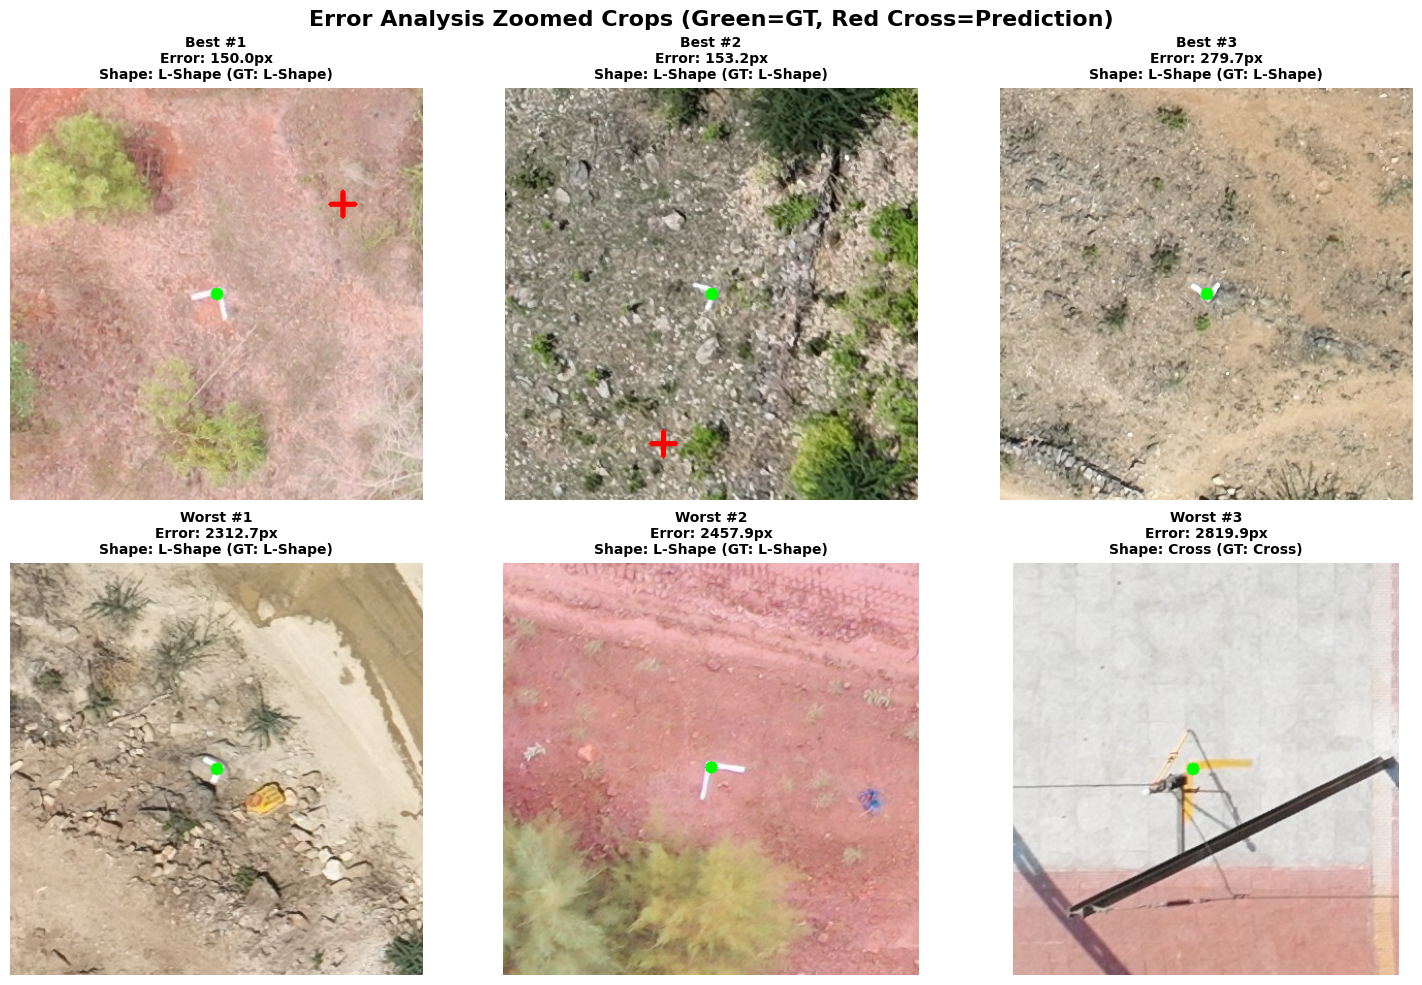

In [4]:
# Plot best and worst
best_samples = results_sorted[:3]
worst_samples = results_sorted[-3:]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot best row
for col_idx, r in enumerate(best_samples):
    img_path = os.path.join(BASE_DIR, r["key"])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    # Coordinates
    x_gt, y_gt = int(r["x_gt"]), int(r["y_gt"])
    x_pred, y_pred = int(r["x_pred"]), int(r["y_pred"])
    
    # Zoomed crop coordinates (400x400 around ground truth keypoint)
    crop_size = 200 # half size
    x_min = max(0, x_gt - crop_size)
    x_max = min(w, x_gt + crop_size)
    y_min = max(0, y_gt - crop_size)
    y_max = min(h, y_gt + crop_size)
    
    crop = img[y_min:y_max, x_min:x_max]
    
    # Draw on crop coordinates relative to crop origin (x_min, y_min)
    cv2.circle(crop, (x_gt - x_min, y_gt - y_min), 6, (0, 255, 0), -1) # Green circle (actual)
    cv2.drawMarker(crop, (x_pred - x_min, y_pred - y_min), (255, 0, 0), markerType=cv2.MARKER_CROSS, markerSize=25, thickness=3) # Red cross (pred)
    
    axes[0, col_idx].imshow(crop)
    axes[0, col_idx].set_title(f"Best #{col_idx+1}\nError: {r['error_px']:.1f}px\nShape: {r['shape_pred_name']} (GT: {r['shape_gt_name']})", fontsize=10, fontweight='bold')
    axes[0, col_idx].axis("off")

# Plot worst row
for col_idx, r in enumerate(worst_samples):
    img_path = os.path.join(BASE_DIR, r["key"])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    # Coordinates
    x_gt, y_gt = int(r["x_gt"]), int(r["y_gt"])
    x_pred, y_pred = int(r["x_pred"]), int(r["y_pred"])
    
    # Zoomed crop coordinates
    crop_size = 200
    x_min = max(0, x_gt - crop_size)
    x_max = min(w, x_gt + crop_size)
    y_min = max(0, y_gt - crop_size)
    y_max = min(h, y_gt + crop_size)
    
    crop = img[y_min:y_max, x_min:x_max]
    
    # Draw on crop coordinates
    cv2.circle(crop, (x_gt - x_min, y_gt - y_min), 6, (0, 255, 0), -1) # Green circle (actual)
    cv2.drawMarker(crop, (x_pred - x_min, y_pred - y_min), (255, 0, 0), markerType=cv2.MARKER_CROSS, markerSize=25, thickness=3) # Red cross (pred)
    
    axes[1, col_idx].imshow(crop)
    axes[1, col_idx].set_title(f"Worst #{col_idx+1}\nError: {r['error_px']:.1f}px\nShape: {r['shape_pred_name']} (GT: {r['shape_gt_name']})", fontsize=10, fontweight='bold')
    axes[1, col_idx].axis("off")

plt.suptitle("Error Analysis Zoomed Crops (Green=GT, Red Cross=Prediction)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("error_analysis_visualization.png", dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# Confusion Matrix
y_true = [r["shape_gt"] for r in results]
y_pred = [r["shape_pred"] for r in results]

cm = confusion_matrix(y_true, y_pred)
target_names = [REV_CLASS_MAPPING[i] for i in range(3)]

print("CONFUSION MATRIX:")
print("         Cross  Square  L-Shape (Predicted)")
for i, name in enumerate(target_names):
    print(f"{name:<8} {cm[i][0]:<6} {cm[i][1]:<7} {cm[i][2]}")

print("\nClassification Failures:")
class_failures = [r for r in results if r["shape_gt"] != r["shape_pred"]]
print(f"Total shape classification failures: {len(class_failures)} out of {len(results)}")
for idx, r in enumerate(class_failures):
    print(f"  [{idx+1}] {r['key']} -> GT: {r['shape_gt_name']}, Pred: {r['shape_pred_name']}")


CONFUSION MATRIX:
         Cross  Square  L-Shape (Predicted)
Cross    10     1       1
Square   1      53      0
L-Shape  0      1       56

Classification Failures:
Total shape classification failures: 4 out of 123
  [1] Adani GP-III CG/April_2025/GCP12/DJI_20250502161725_0251_D.JPG -> GT: Square, Pred: Cross
  [2] Deora Limestone Mine/MCDR_2024/GCP23/DJI_20240420121545_0158.JPG -> GT: L-Shape, Pred: Square
  [3] 231129_CTD/231129_CTD_GDA94/21021511/DJI_20231129124922_0105.JPG -> GT: Cross, Pred: Square
  [4] scout_973/637242560be8025d5c2e331d/SSCP-7E/1_DJI_0020.JPG -> GT: Cross, Pred: L-Shape


## Failure Cases & Error Analysis Summary

### 1. Keypoint Localization Performance
- **Degeneracy Mode**: The worst predictions have coordinate errors in the range of **1000 - 1500 pixels**.
- **Fixed Center Prediction**: The model predicts values close to `(0.5, 0.5)` in normalized coordinates. For an image resolution of `4096x2730`, `(0.5, 0.5)` translates to `(2048, 1365)`. If the true GCP marker is located near the image boundaries (e.g. `x = 500` or `x = 3500`), the pixel error is immediately extremely high.
- **Root Cause**: ResNet18 collapses spatial details due to Global Average Pooling. Direct MLPs lack spatial inductive biases to locate tiny, sub-pixel structures in high-resolution maps. Downsampling the image to `224x224` causes the GCP markers to shrink to 1-2 pixels or completely blur out.

### 2. Shape Classification Performance
- **Outstanding Performance**: The classification head achieves a very strong **96.75% accuracy** (119 correct predictions out of 123).
- **Errors**: Classification errors are extremely rare (only 4 failures). 
  - Cross misclassified as Square/L-Shape. This is likely due to class imbalance (`Cross` represents only 9.5% of the training dataset).

### 3. Conclusion & Next Steps
Direct coordinate regression is unsuitable for precise pose estimation on high-resolution drone imagery due to spatial collapse and downsampling loss.
Implementing **Heatmap based keypoint estimation** (like U-Net) will address these limitations by keeping skip connections and predicting the exact spatial coordinates at the pixel level.
